In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:

class KB_Game:
    def __init__(self, *args, **kwargs):
        self.q = np.array([0.0, 0.0, 0.0])  # 每个臂的平均汇报回报
        self.action_counts = np.array([0, 0, 0])  # 摇动每个臂的次数
        self.current_cumulative_rewards = 0.0  # 累计回报总和
        self.actions = [1, 2, 3]  # 动作空间，1，2，3表示三个不同的摇臂
        self.counts = 0  # 玩家玩游戏的次数
        self.counts_history = []  # 玩家玩游戏的次数记录
        self.current_cumulative_rewards_history = []  # 累积回报的记录
        self.a = 1  # 玩家当前动作，初始值可以为动作空间中任意一个动作，这里是去摇动第一个臂
        self.reward = 0  # 当前回报，初始值为0

    def step(self, a):
        r = 0
        if a == 1:  # 摇动摇臂1
            r = np.random.normal(1, 1)  # 回报符合均值为1，标准差为1的正态分布
        if a == 2:
            r = np.random.normal(2, 1)  # 回报符合均值为2，标准差为1的正态分布
        if a == 3:
            r = np.random.normal(1.5, 1)  # 回报符合均值为1.5，标准差为1的正态分布
        return r

    def choose_action(self, policy, **kwargs):  # kwargs是一个dict，python自带的，这里传递的是策略对应的超参数，
        action = 0
        if policy == 'e_greedy':  # e_greedy方法
            if np.random.random() < kwargs['epsilon']:
                # np.random.random()是0~1的随机数，kwargs['epsilon']对应的是epsilon（那个希腊符号）
                action = np.random.randint(1, 4)  # random.randint(1, 4)是返回1~4-1的一个随机整型
            else:
                action = np.argmax(self.q) + 1  # 返回平均回报最大的那个
        if policy == 'ucb':  # ucb策略可以看https://blog.csdn.net/songyunli1111/article/details/83384738
            c_ratio = kwargs['c_ratio']
            if 0 in self.action_counts:  # 在有哪一个没试过一次的情况下
                action = np.where(self.action_counts == 0)[0][0] + 1  # 就去试一下那个臂
            else:
                value = self.q + c_ratio*np.sqrt(np.log(self.counts)/self.action_counts)  # 算法实现
                action = np.argmax(value) + 1  # 感觉这个怪怪的，直接找value最大的？
        if policy == 'boltzmann':  # 玻尔兹曼方法
            tau = kwargs['temperature']
            p = np.exp(self.q/tau)/(np.sum(np.exp(self.q/tau)))  # p是抽取每个臂的概率，一个不知道几维的数组
            action = np.random.choice([1, 2, 3], p=p.ravel())
            # ravel函数是把p拉成一维数组，这里np.random.choice的前一个参数是选取范围，后一个是各个的概率
        return action

    # 这里play_total是它的训练的总次数，policy是训练方法(e_greedy之类)，**kwargs是它的超参数(temperature之类)
    def train(self, play_total, policy, **kwargs):
        # 下面这几个reward我是不太明白，估计是在看到结果后，调出reward就能看到平均回报的变化，在这个程序里应该是没有用上的
        reward_1 = []
        reward_2 = []
        reward_3 = []
        for i in range(play_total):  # 总共玩多少次
            action = 0
            if policy == 'e_greedy':  # 选择方法
                action = self.choose_action(policy, epsilon=kwargs['epsilon'])
            if policy == 'ucb':
                action = self.choose_action(policy, c_ratio=kwargs['c_ratio'])
            if policy == 'boltzmann':
                action = self.choose_action(policy, temperature=kwargs['temperature'])
            self.a = action
            # print(self.a) 打印的是整型数字
            # 与环境交互一次
            self.reward = self.step(self.a)  # 说实话我感觉应该写成reward，书上啥都有，这里都写成了r，那就改过来吧
            self.counts += 1
            # 更新值函数
            self.q[self.a-1] = (self.q[self.a-1]*self.action_counts[self.a-1]+self.reward)/(self.action_counts[self.a-1]+1)
            # 更新平均回报
            self.action_counts[self.a-1] += 1
            reward_1.append([self.q[0]])
            reward_2.append([self.q[1]])
            reward_3.append([self.q[2]])
            # 下面是对累计回报和历史累计回报进行更新
            self.current_cumulative_rewards += self.reward
            self.current_cumulative_rewards_history.append(self.current_cumulative_rewards)
            self.counts_history.append(i)

    def reset(self):  # 只是把init函数里的actions删掉了而已，这个是用来重置KB_Game中的成员变量的函数
        self.q = np.array([0.0, 0.0, 0.0])
        self.action_counts = np.array([0, 0, 0])
        self.current_cumulative_rewards = 0.0
        self.counts = 0
        self.counts_history = []
        self.current_cumulative_rewards_history = []  # self.cumulative_rewards_history = []书上是这玩意
        self.a = 1
        self.reward = 0

    def plot(self, colors, policy):  # 绘图函数
        plt.figure(1)
        plt.plot(self.counts_history, self.current_cumulative_rewards_history, colors, label=policy)
        plt.legend()
        plt.xlabel('n', fontsize=18)
        plt.ylabel('total rewards', fontsize=18)

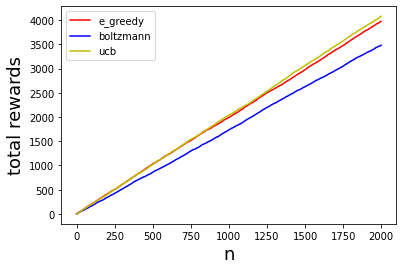

In [5]:
np.random.seed(999)  # 要改成时间不同就不同的话就把0改掉就行了
k_gamble = KB_Game()
total = 2000  # 总共游玩的次数
# 下面是各个方法的使用了，就不一个个强调了
k_gamble.train(play_total=total, policy='e_greedy', epsilon=0.05)
k_gamble.plot(colors='r', policy='e_greedy')  # 这书上的plot函数本来就没有style传进去，看来得改改，把style删了哈哈哈
k_gamble.reset()
k_gamble.train(play_total=total, policy='boltzmann', temperature=1)
k_gamble.plot(colors='b', policy='boltzmann')
k_gamble.reset()
k_gamble.train(play_total=total, policy='ucb', c_ratio=0.5)
k_gamble.plot(colors='y', policy='ucb')
plt.show()